# Previsão de Churn com PyTorch + Optuna

Pipeline completo: MLP customizável, Early Stopping, AUC-ROC e otimização de hiperparâmetros.

## 1. Instalação de Dependências

In [1]:
# !pip install torch optuna scikit-learn pandas numpy --quiet

## 2. Imports

In [2]:
from __future__ import annotations

import warnings
from typing import Any

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

from churn_telecom.config import (
    DATA_PROCESSED,
)

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"Dispositivo: {DEVICE}")

Dispositivo: cpu


## 3. Variáveis de Entrada

> **Pré-requisito:** `train` e `test` já devem estar carregados como DataFrames pandas antes desta célula.

In [3]:
TRAIN_PATH = DATA_PROCESSED / "train.parquet"
TEST_PATH = DATA_PROCESSED / "test.parquet"

assert TRAIN_PATH.exists(), f"Arquivo não encontrado: {TRAIN_PATH}"
assert TEST_PATH.exists(), f"Arquivo não encontrado: {TEST_PATH}"

train = pd.read_parquet(TRAIN_PATH)
test = pd.read_parquet(TEST_PATH)

In [4]:
TARGET = "churn_value"

X_train: pd.DataFrame = train.drop(columns=[TARGET])  # noqa: F821
y_train: pd.Series = train[TARGET]  # noqa: F821
X_test: pd.DataFrame = test.drop(columns=[TARGET])  # noqa: F821
y_test: pd.Series = test[TARGET]  # noqa: F821

print(f"Treino : {X_train.shape} | Teste: {X_test.shape}")
print(f"Balanceamento treino — churn=1: {y_train.mean():.2%}")

Treino : (5395, 30) | Teste: (1405, 30)
Balanceamento treino — churn=1: 57.41%


## 4. Pré-processamento

In [5]:
def preprocess(
    X_tr: pd.DataFrame,
    X_te: pd.DataFrame,
) -> tuple[np.ndarray, np.ndarray]:
    """Padroniza features numéricas usando estatísticas do treino."""
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr.select_dtypes(include="number"))
    X_te_scaled = scaler.transform(X_te.select_dtypes(include="number"))
    return X_tr_scaled, X_te_scaled


X_train_np, X_test_np = preprocess(X_train, X_test)
y_train_np = y_train.to_numpy(dtype=np.float32)
y_test_np = y_test.to_numpy(dtype=np.float32)

N_FEATURES = X_train_np.shape[1]
print(f"Features após pré-processamento: {N_FEATURES}")

Features após pré-processamento: 30


## 5. Pipeline de Dados — TensorDataset + DataLoader

In [6]:
def make_loaders(
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    X_te: np.ndarray,
    y_te: np.ndarray,
    batch_size: int = 64,
    val_split: float = 0.15,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    """Cria DataLoaders de treino, validação e teste."""
    n_val = int(len(X_tr) * val_split)
    idx = np.random.permutation(len(X_tr))
    val_idx, train_idx = idx[:n_val], idx[n_val:]

    def _to_tensor(X: np.ndarray, y: np.ndarray) -> TensorDataset:
        return TensorDataset(
            torch.tensor(X, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
        )

    train_ds = _to_tensor(X_tr[train_idx], y_tr[train_idx])
    val_ds = _to_tensor(X_tr[val_idx], y_tr[val_idx])
    test_ds = _to_tensor(X_te, y_te)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size)
    test_loader = DataLoader(test_ds, batch_size=batch_size)

    return train_loader, val_loader, test_loader

## 6. Arquitetura MLP — `ChurnMLP`

In [7]:
class ChurnMLP(nn.Module):
    """Rede MLP parametrizável para classificação binária de churn.

    Args:
        input_dim:    Número de features de entrada.
        hidden_units: Lista com o nº de neurônios por camada oculta.
        dropout_rate: Taxa de dropout aplicada após cada camada oculta.
    """

    def __init__(
        self,
        input_dim: int,
        hidden_units: list[int],
        dropout_rate: float = 0.3,
    ) -> None:
        super().__init__()

        layers: list[nn.Module] = []
        in_dim = input_dim

        for units in hidden_units:
            layers += [
                nn.Linear(in_dim, units),
                nn.BatchNorm1d(units),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
            ]
            in_dim = units

        layers += [nn.Linear(in_dim, 1), nn.Sigmoid()]
        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:  # noqa: D102
        return self.network(x).squeeze(1)


# Teste rápido de sanidade
_demo = ChurnMLP(N_FEATURES, [64, 32], 0.3).to(DEVICE)
_x = torch.randn(8, N_FEATURES).to(DEVICE)
assert _demo(_x).shape == (8,), "Shape de saída incorreto!"
print("Arquitetura validada:", _demo)

Arquitetura validada: ChurnMLP(
  (network): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
    (9): Sigmoid()
  )
)


## 7. Early Stopping

In [8]:
class EarlyStopping:
    """Interrompe o treino quando a perda de validação para de melhorar.

    Args:
        patience:  Épocas sem melhora antes de parar.
        min_delta: Melhora mínima considerada significativa.
    """

    def __init__(self, patience: int = 10, min_delta: float = 1e-4) -> None:
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss: float = float("inf")
        self.best_weights: dict[str, Any] | None = None

    def step(self, val_loss: float, model: nn.Module) -> bool:
        """Retorna True se o treino deve parar."""
        import copy

        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_weights = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1

        return self.counter >= self.patience

    def restore(self, model: nn.Module) -> None:
        """Restaura os pesos do melhor checkpoint."""
        if self.best_weights is not None:
            model.load_state_dict(self.best_weights)

## 8. Loop de Treinamento

In [9]:
def train_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
) -> float:
    """Executa uma época de treino e retorna a perda média."""
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
    return total_loss / len(loader.dataset)  # type: ignore[arg-type]


@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
) -> tuple[float, float]:
    """Avalia o modelo e retorna (perda, AUC-ROC)."""
    model.eval()
    total_loss = 0.0
    all_probs: list[np.ndarray] = []
    all_labels: list[np.ndarray] = []

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        probs = model(X_batch)
        loss = criterion(probs, y_batch)
        total_loss += loss.item() * len(y_batch)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)  # type: ignore[arg-type]
    auc = roc_auc_score(np.concatenate(all_labels), np.concatenate(all_probs))
    return avg_loss, auc


def fit(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    *,
    lr: float = 1e-3,
    max_epochs: int = 100,
    patience: int = 10,
    verbose: bool = True,
) -> dict[str, list[float]]:
    """Treina o modelo com Early Stopping. Retorna histórico de métricas."""
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    stopper = EarlyStopping(patience=patience)
    history: dict[str, list[float]] = {"train_loss": [], "val_loss": [], "val_auc": []}

    for epoch in range(1, max_epochs + 1):
        tr_loss = train_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_auc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)
        history["val_auc"].append(val_auc)

        if verbose and epoch % 10 == 0:
            print(
                f"Época {epoch:>3} | "
                f"Treino Loss: {tr_loss:.4f} | "
                f"Val Loss: {val_loss:.4f} | "
                f"Val AUC: {val_auc:.4f}"
            )

        if stopper.step(val_loss, model):
            if verbose:
                print(f"Early stopping na época {epoch}.")
            break

    stopper.restore(model)
    return history

## 9. Otimização de Hiperparâmetros com Optuna

In [10]:
def objective(trial: optuna.Trial) -> float:
    """Função objetivo: maximiza AUC-ROC de validação."""
    # --- Hiperparâmetros sugeridos pelo Optuna ---
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128, 256])
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)
    n_layers = trial.suggest_int("n_layers", 1, 4)
    hidden_units = [
        trial.suggest_categorical(f"units_l{i}", [32, 64, 128, 256])
        for i in range(n_layers)
    ]

    # --- Pipeline de dados ---
    train_loader, val_loader, _ = make_loaders(
        X_train_np,
        y_train_np,
        X_test_np,
        y_test_np,
        batch_size=int(batch_size),
    )

    # --- Modelo ---
    model = ChurnMLP(
        input_dim=N_FEATURES,
        hidden_units=hidden_units,
        dropout_rate=dropout_rate,
    ).to(DEVICE)

    # --- Treino (silencioso, sem verbose) ---
    history = fit(
        model,
        train_loader,
        val_loader,
        lr=lr,
        max_epochs=80,
        patience=8,
        verbose=False,
    )

    return max(history["val_auc"])


N_TRIALS = 30  # Aumente para buscas mais amplas

study = optuna.create_study(
    direction="maximize",
    study_name="churn_mlp",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("\n=== Melhores Hiperparâmetros ===")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")
print(f"\nMelhor AUC-ROC (validação): {study.best_value:.4f}")

  0%|          | 0/30 [00:00<?, ?it/s]


=== Melhores Hiperparâmetros ===
  lr: 0.000661859559718348
  batch_size: 32
  dropout_rate: 0.16448851490160177
  n_layers: 4
  units_l0: 128
  units_l1: 64
  units_l2: 32
  units_l3: 128

Melhor AUC-ROC (validação): 0.9990


## 10. Treinamento Final com Melhores Hiperparâmetros

In [11]:
best = study.best_params

best_hidden_units = [best[f"units_l{i}"] for i in range(best["n_layers"])]

train_loader, val_loader, test_loader = make_loaders(
    X_train_np,
    y_train_np,
    X_test_np,
    y_test_np,
    batch_size=int(best["batch_size"]),
)

best_model = ChurnMLP(
    input_dim=N_FEATURES,
    hidden_units=best_hidden_units,
    dropout_rate=best["dropout_rate"],
).to(DEVICE)

print("Treinando modelo final...")
history = fit(
    best_model,
    train_loader,
    val_loader,
    lr=best["lr"],
    max_epochs=150,
    patience=15,
    verbose=True,
)

Treinando modelo final...
Época  10 | Treino Loss: 0.1350 | Val Loss: 0.1240 | Val AUC: 0.9910
Época  20 | Treino Loss: 0.1094 | Val Loss: 0.1120 | Val AUC: 0.9925
Época  30 | Treino Loss: 0.0832 | Val Loss: 0.1007 | Val AUC: 0.9931
Época  40 | Treino Loss: 0.0692 | Val Loss: 0.1003 | Val AUC: 0.9939
Época  50 | Treino Loss: 0.0599 | Val Loss: 0.0920 | Val AUC: 0.9944
Época  60 | Treino Loss: 0.0536 | Val Loss: 0.1025 | Val AUC: 0.9930
Early stopping na época 60.


## 11. Avaliação no Conjunto de Teste

In [12]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
)

criterion = nn.BCELoss()
test_loss, test_auc = evaluate(best_model, test_loader, criterion)

# Predições binárias com threshold 0.5
best_model.eval()
all_probs_list: list[np.ndarray] = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        all_probs_list.append(best_model(X_batch.to(DEVICE)).cpu().numpy())

probs_test = np.concatenate(all_probs_list)
preds_test = (probs_test >= 0.5).astype(int)

print(f"Teste — Loss: {test_loss:.4f} | AUC-ROC: {test_auc:.4f}")
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test_np, preds_test))
print("\nRelatório de Classificação:")
print(classification_report(y_test_np, preds_test, target_names=["Não-Churn", "Churn"]))

Teste — Loss: 1.2717 | AUC-ROC: 0.8297

Matriz de Confusão:
[[727 306]
 [ 70 302]]

Relatório de Classificação:
              precision    recall  f1-score   support

   Não-Churn       0.91      0.70      0.79      1033
       Churn       0.50      0.81      0.62       372

    accuracy                           0.73      1405
   macro avg       0.70      0.76      0.71      1405
weighted avg       0.80      0.73      0.75      1405



## 12. Visualizações

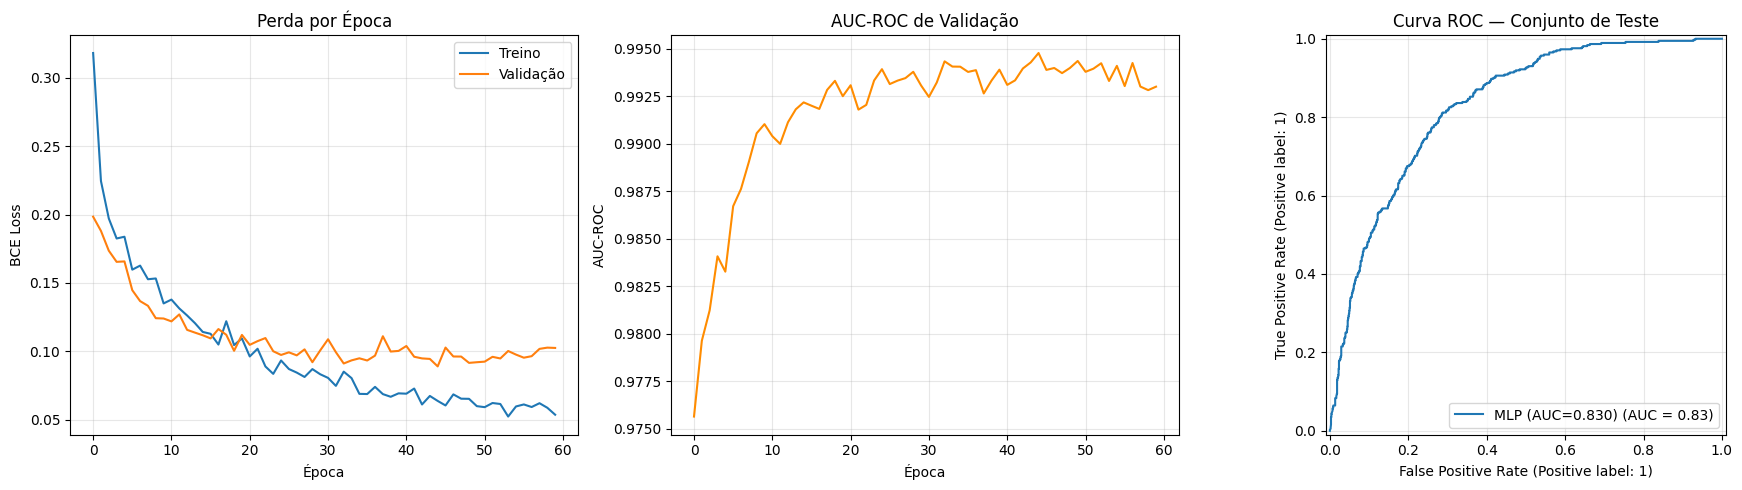

Figura salva em churn_results.png


In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Curva de Perda ---
ax = axes[0]
ax.plot(history["train_loss"], label="Treino")
ax.plot(history["val_loss"], label="Validação")
ax.set_title("Perda por Época")
ax.set_xlabel("Época")
ax.set_ylabel("BCE Loss")
ax.legend()
ax.grid(alpha=0.3)

# --- Curva AUC-ROC por Época ---
ax = axes[1]
ax.plot(history["val_auc"], color="darkorange")
ax.set_title("AUC-ROC de Validação")
ax.set_xlabel("Época")
ax.set_ylabel("AUC-ROC")
ax.grid(alpha=0.3)

# --- Curva ROC no Teste ---
RocCurveDisplay.from_predictions(
    y_test_np, probs_test, ax=axes[2], name=f"MLP (AUC={test_auc:.3f})"
)
axes[2].set_title("Curva ROC — Conjunto de Teste")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("churn_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salva em churn_results.png")

## 13. Exportação do Modelo

In [14]:
torch.save(
    {
        "model_state_dict": best_model.state_dict(),
        "hyperparams": best,
        "n_features": N_FEATURES,
        "test_auc": test_auc,
    },
    "churn_mlp_best.pt",
)
print("Modelo salvo em churn_mlp_best.pt")

# --- Como recarregar ---
# checkpoint = torch.load("churn_mlp_best.pt", map_location=DEVICE)
# loaded_model = ChurnMLP(
#     input_dim=checkpoint["n_features"],
#     hidden_units=[checkpoint["hyperparams"][f"units_l{i}"]
#                   for i in range(checkpoint["hyperparams"]["n_layers"])],
#     dropout_rate=checkpoint["hyperparams"]["dropout_rate"],
# )
# loaded_model.load_state_dict(checkpoint["model_state_dict"])
# loaded_model.eval()

Modelo salvo em churn_mlp_best.pt
